INSTALL DEPENDENCIES


In [ ]:
!pip install pandas numpy scikit-learn lightgbm shap matplotlib seaborn


IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import lightgbm as lgb
import shap


LOADING DATASET

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


PREVIEW DATA

In [ ]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


CHECK MISSING VALUES

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


DATA CLEANING

In [ ]:
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


Missing TotalCharges: 11


/tmp/ipython-input-2945806404.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


TARGET VARIABLE ENCODING

In [ ]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

ENCODE CATEGORICAL FEATURES

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

FEATURE & TARGET SPLIT

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


TRAIN–TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

TRAIN MULTIPLE MODELS (COMPARISON)

Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7991483321504613


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7892122072391767


LightGBM

In [ ]:
lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]

lgbm_acc = accuracy_score(y_test, lgbm_pred)

print("LightGBM Accuracy:", lgbm_acc)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
LightGBM Accuracy: 0.7998580553584103


MODEL COMPARISON

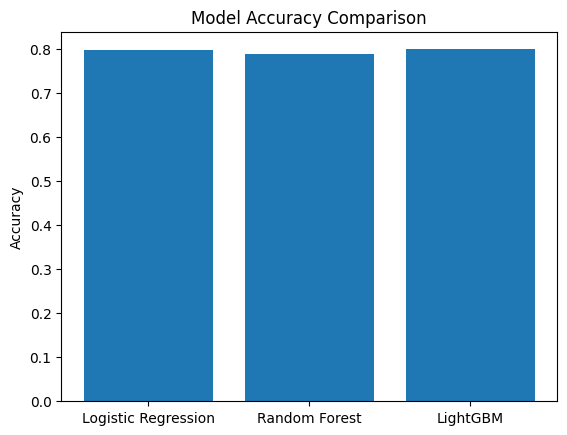

In [ ]:
models = ["Logistic Regression", "Random Forest", "LightGBM"]
accuracies = [lr_acc, rf_acc, lgbm_acc]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

DETAILED EVALUATION

In [ ]:
print("ROC-AUC:", roc_auc_score(y_test, lgbm_prob))
print(classification_report(y_test, lgbm_pred))

ROC-AUC: 0.8327236559973135
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



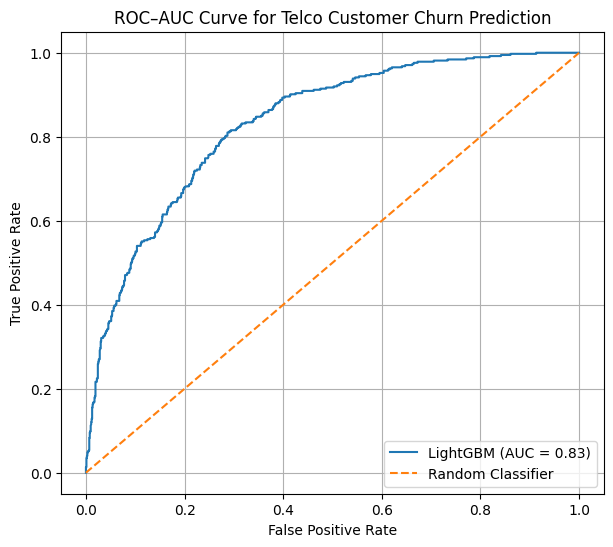

ROC–AUC Score: 0.8327236559973135


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
y_prob = lgbm.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"LightGBM (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve for Telco Customer Churn Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
print("ROC–AUC Score:", roc_auc)


CONFUSION MATRIX

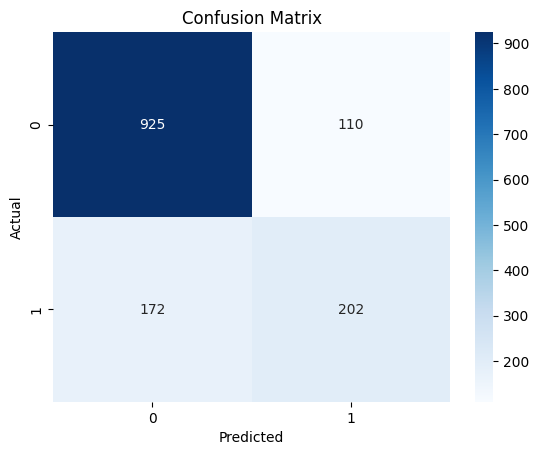

In [ ]:
cm = confusion_matrix(y_test, lgbm_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

FEATURE IMPORTANCE

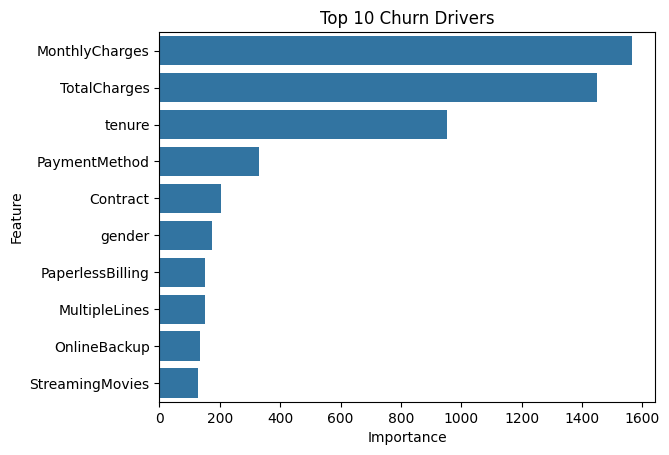

In [ ]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm.feature_importances_
}).sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10))
plt.title("Top 10 Churn Drivers")
plt.show()

SHAP EXPLAINABILITY

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


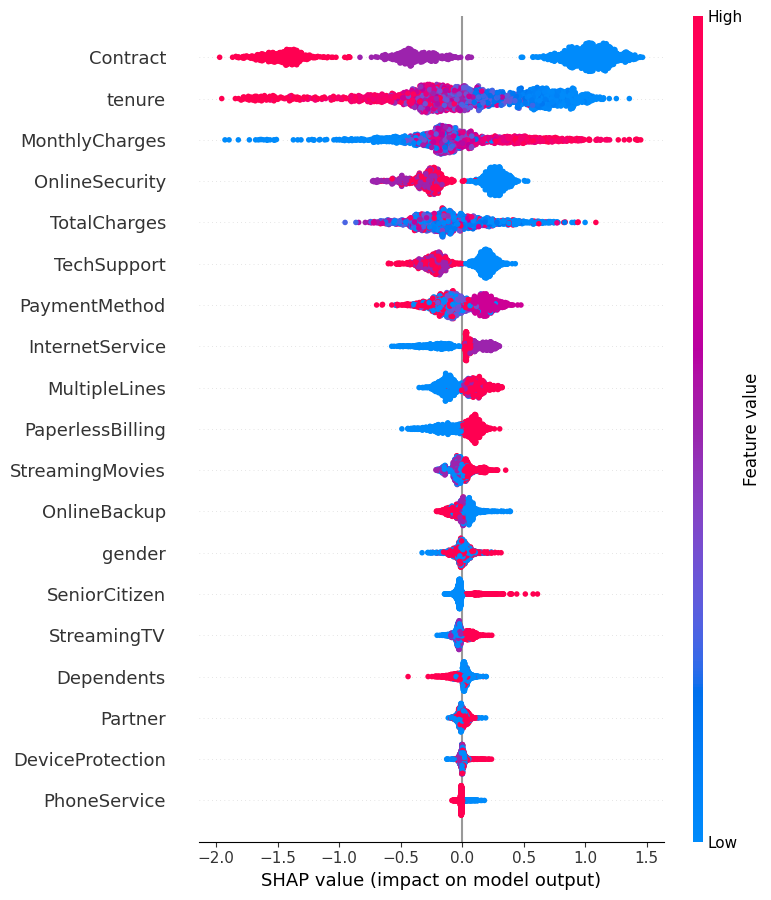

In [ ]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

EXPLAIN SINGLE CUSTOMER

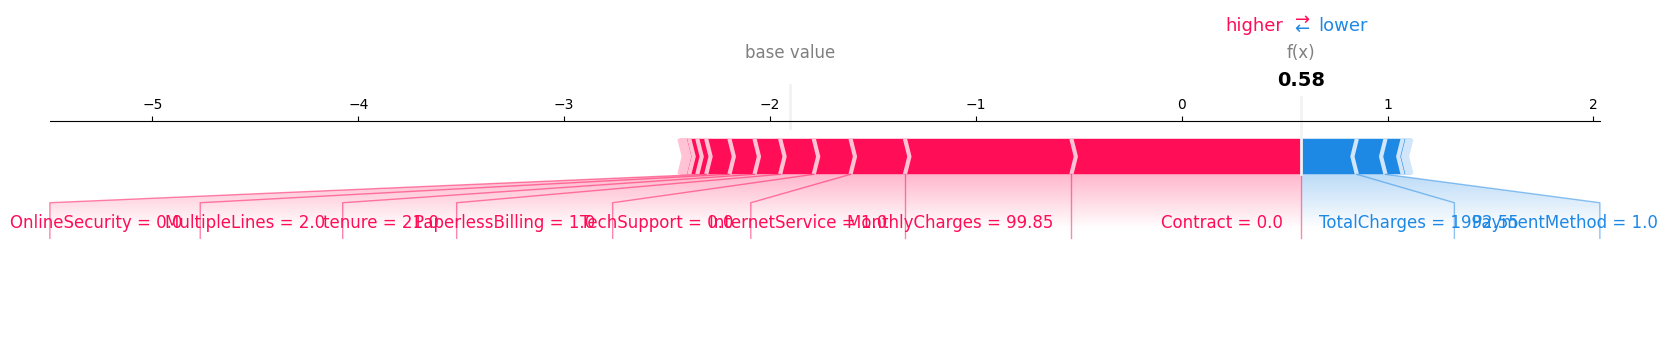

In [ ]:
index = 5
shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_test.iloc[index],
    matplotlib=True
)

AI AGENTS

Churn Prediction Agent

In [ ]:
def churn_prediction_agent(customer_data):
    prob = lgbm.predict_proba(customer_data)[0][1]
    return prob

Explanation Agent

In [ ]:
def explanation_agent(customer_data, index):
    shap_vals = shap_values[index]
    top_features = np.argsort(np.abs(shap_vals))[-3:]

    reasons = [X.columns[i] for i in top_features]

    return f"Customer likely to churn due to: {', '.join(reasons)}"

Agent Execution

In [ ]:
customer = X_test.iloc[[0]]

churn_prob = churn_prediction_agent(customer)
explanation = explanation_agent(customer, 0)

print("Churn Probability:", churn_prob)
print("Explanation:", explanation)

Churn Probability: 0.003373483078916748
Explanation: Customer likely to churn due to: TotalCharges, tenure, Contract


CUSTOMER RISK SEGMENTATION

In [ ]:
def risk_segment(prob):
    if prob >= 0.7:
        return "High Risk 🔴"
    elif prob >= 0.4:
        return "Medium Risk 🟡"
    else:
        return "Low Risk 🟢"

risk_df = X_test.copy()
risk_df["Churn_Probability"] = lgbm_prob
risk_df["Risk_Segment"] = risk_df["Churn_Probability"].apply(risk_segment)

risk_df[["Churn_Probability", "Risk_Segment"]].head()

,Churn_Probability,Risk_Segment
437,0.003373,Low Risk 🟢
2280,0.888591,High Risk 🔴
2235,0.066487,Low Risk 🟢
4460,0.267109,Low Risk 🟢
3761,0.004491,Low Risk 🟢


AI CHURN PREDICTION AGENT

In [ ]:
def churn_prediction_agent(customer_data):
    probability = lgbm.predict_proba(customer_data)[0][1]
    return probability

# Call the agent
customer = X_test.iloc[[0]]
churn_prob = churn_prediction_agent(customer)

print("Churn Probability:", churn_prob)

Churn Probability: 0.003373483078916748


AI EXPLANATION AGENT

In [ ]:
def explanation_agent(index):
    shap_vals = shap_values[index]
    top_features = np.argsort(np.abs(shap_vals))[-3:]
    reasons = [X.columns[i] for i in top_features]

    return (
        f"This customer shows a high risk of churn mainly due to "
        f"{reasons[0]}, {reasons[1]}, and {reasons[2]}."
    )

print(explanation_agent(0))


This customer shows a high risk of churn mainly due to TotalCharges, tenure, and Contract.


AI RETENTION RECOMMENDATION AGENT


In [ ]:

customer = X_test.iloc[0]   # single row (Series)
churn_prob = churn_prediction_agent(X_test.iloc[[0]])
output = retention_agent(customer, churn_prob)
print("Retention Suggestions:")
for o in output:
    print("-", o)

Retention Suggestions:
- Migrate to optimized pricing plan


FAIRNESS & BIAS CHECK

In [ ]:
def fairness_check(feature):
    groups = df[feature].unique()
    for g in groups:
        group_data = df[df[feature] == g]
        X_g = group_data.drop("Churn", axis=1)
        y_g = group_data["Churn"]
        prob = lgbm.predict_proba(X_g)[:,1].mean()
        print(f"{feature} = {g} → Avg Churn Risk: {prob:.2f}")

Taking Gender atrribute for fairness check

In [ ]:
fairness_check("gender")

gender = 0 → Avg Churn Risk: 0.26
gender = 1 → Avg Churn Risk: 0.26


BUSINESS INSIGHTS DASHBOARD

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


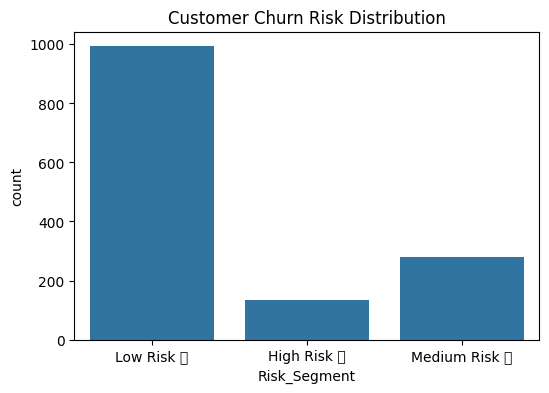

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=risk_df["Risk_Segment"])
plt.title("Customer Churn Risk Distribution")
plt.show()

Export High Risk Customers

In [ ]:
high_risk_customers = risk_df[risk_df["Risk_Segment"] == "High Risk 🔴"]
high_risk_customers.to_csv("high_risk_customers.csv", index=False)

In [ ]:
high_risk_customers.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Risk_Segment
2280,0,1,0,0,8,1,2,1,0,0,...,2,2,2,0,1,1,100.15,908.55,0.888591,High Risk 🔴
3524,0,1,0,0,11,1,2,1,0,0,...,0,0,2,0,1,1,84.80,906.85,0.712071,High Risk 🔴
6529,1,1,0,0,2,1,2,1,0,0,...,0,0,0,0,1,3,74.85,156.40,0.774848,High Risk 🔴
346,0,0,0,0,2,1,0,1,0,0,...,0,2,2,0,1,2,90.40,168.20,0.843610,High Risk 🔴
6633,0,0,0,0,1,1,2,1,0,0,...,0,0,0,0,1,2,74.50,74.50,0.864058,High Risk 🔴


In [ ]:
from google.colab import files
files.download("high_risk_customers.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>